<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 700; line-height: 1.2;">
        ¿Pandas, Seaborn o Matplotlib?
      </h1>
      <p style="margin: 6px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Programación para Ciencia de Datos
      </p>
    </td>
    <td style="vertical-align: middle; text-align: right; border: none; padding: 15px 20px; min-width: 240px; font-family: system-ui, -apple-system, sans-serif;">
      <div style="font-size: 0.9em; color: #334155; line-height: 1.5;">
        <strong style="color: #1e3a8a; font-size: 1em;">Especialización en Ciencia de Datos</strong><br>
        <span style="color: #475569; font-weight: 600;">USTA Tunja</span><br><br>
        <b>Santiago A. Zúñiga M.</b><br>
        ✉️ <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
      </div>
    </td>
  </tr>
</table>

---
## 1. El Dilema de la Visualización 🎨

A la hora de graficar en Python, puedes pensar en usar uno de estos cuatro enfoques:

### Enfoque 1: Solo Pandas
- **Curva de Aprendizaje:** Fácil
- **Visual por defecto:** Malo
- **Personalización Visual:** Regular
- 💡 **TIP:** Solo conocer cuáles son los métodos de trazado implementados en Pandas es suficiente para extraer información rápida para ti (pero tal vez no para una presentación final).

### Enfoque 2: Pandas + Matplotlib
- **Curva de Aprendizaje:** Difícil
- **Visual por defecto:** Regular
- **Personalización Visual:** Excelente pero engañoso (se trata de aprender Matplotlib desde cero)
- 💡 **TIP:** Piensa en el gráfico que quieres, luego usa `DataFrame.groupby` o aplica alguna condición al DataFrame para alimentar tus gráficos de Matplotlib iterando sobre ellos.

### Enfoque 3: Pandas + Seaborn
- **Curva de Aprendizaje:** Buena
- **Visual por defecto:** Bueno
- **Personalización Visual:** Muy Buena
- 💡 **TIP:** Trabajar con Seaborn se trata casi exclusivamente de **preparar el DataFrame** para alimentar el gráfico de la forma que Seaborn requiere. Necesitas aprender los gráficos disponibles y gastar tiempo aprendiendo métodos como `melt` o `pivot`.

### Enfoque 4: Pandas + Matplotlib + Seaborn
- **Curva de Aprendizaje:** Difícil
- **Visual por defecto:** Bueno
- **Personalización Visual:** Excelente
- 💡 **TIP:** El cielo es el límite. Recuerda que Seaborn fue construido sobre Matplotlib, así que puedes combinarlos libremente.

---
## Preparación del Dataset

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

palette = 'pastel'
sns.set_palette(palette)

# Cargaremos el mismo dataset de estudiantes del notebook anterior para mantener el contexto
df = pd.read_csv('data/StudentsPerformance.csv').rename(
    columns={
        'race/ethnicity': 'group',
        'parental level of education': 'parental',
        'test preparation course': 'course',
        'math score': 'math',
        'reading score': 'reading',
        'writing score': 'writing'
    }
)

# Recreamos la columna dummy de 'approved' para los ejemplos
df['approved'] = (df['math'] >= 40).astype(int)
df.head()

,gender,group,parental,lunch,course,math,reading,writing,approved
0,female,group B,bachelor's degree,standard,none,72,72,74,1
1,female,group C,some college,standard,completed,69,90,88,1
2,female,group B,master's degree,standard,none,90,95,93,1
3,male,group A,associate's degree,free/reduced,none,47,57,44,1
4,male,group C,some college,standard,none,76,78,75,1


---
## 2. Comparación en la Práctica ⚔️

Analicemos un mismo problema visual resuelto con los distintos enfoques.

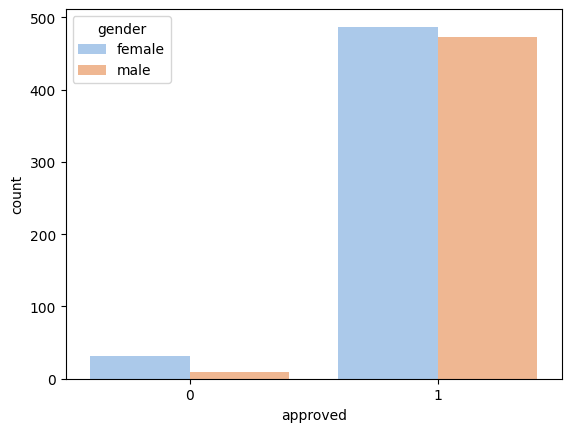

In [2]:
# Empecemos con un recuento rápido (Pandas + Seaborn)
sns.countplot(data=df, x='approved', hue='gender', palette=palette);

### 2.1 Pandas + Matplotlib (Bucle Crudo)
Queremos hacer un histograma de los puntajes de matemáticas, separado por quiénes aprobaron y su género.

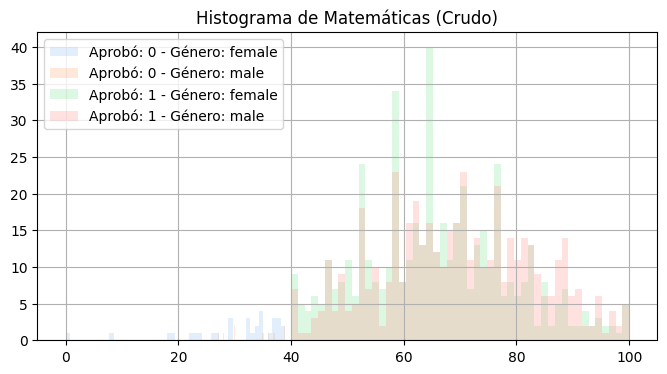

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))

# Agrupamos por múltiples columnas y recorremos el iterador
for group, g in df.groupby(['approved', 'gender']):
    # group es una tupla: (0, 'female'), (1, 'male'), etc.
    g[['math']].hist(bins=50, ax=ax, alpha=.3, label=f'Aprobó: {group[0]} - Género: {group[1]}')
    
plt.legend();
plt.title('Histograma de Matemáticas (Crudo)');

### 2.2 Pandas + Seaborn (FacetGrid)
Para hacer el mismo análisis con Seaborn, podemos usar la maravilla del `FacetGrid` separando por filas y columnas sin tener que usar bucles manuales de Matplotlib.

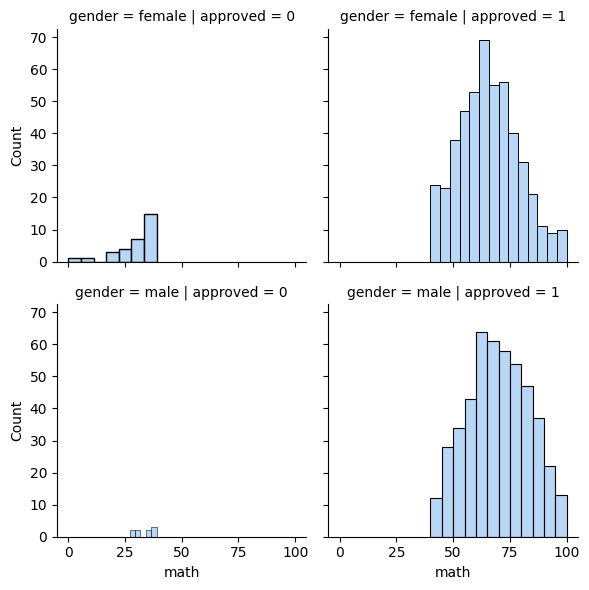

In [4]:
g = sns.FacetGrid(df, col='approved', row='gender', palette=palette)
g.map(sns.histplot, 'math');

Podemos repetir esto con un clic para el resto de áreas, demostrando por qué a veces **es mejor buscar alternativas modulares** en lugar de codificar bucles a mano.

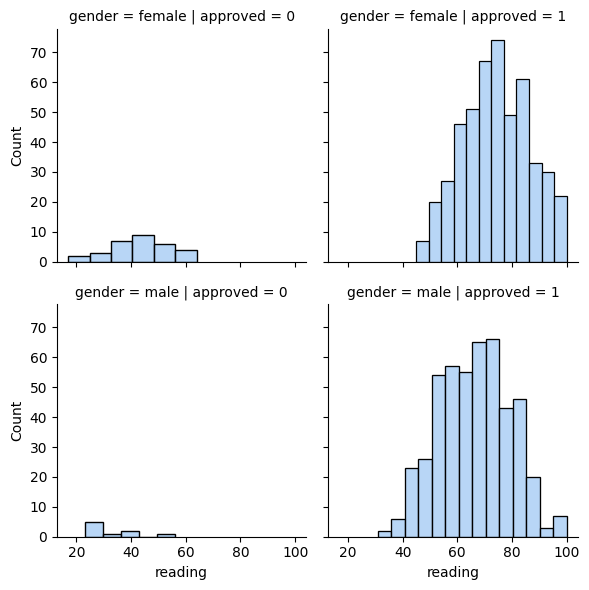

In [5]:
g = sns.FacetGrid(df, col='approved', row='gender', palette=palette)
g.map(sns.histplot, 'reading');

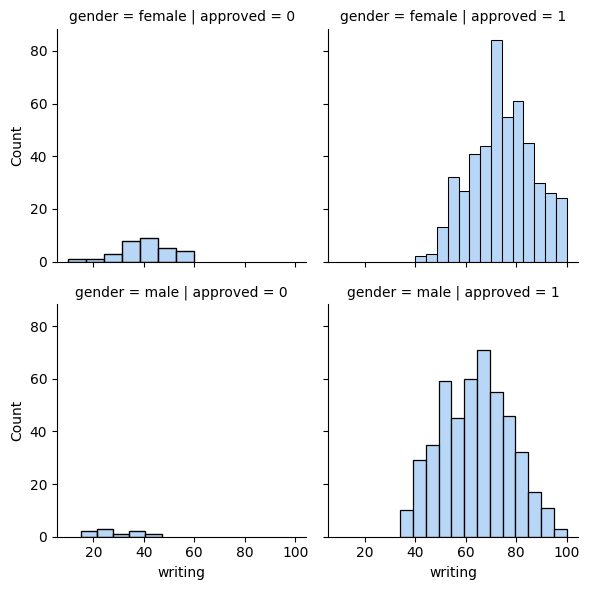

In [6]:
g = sns.FacetGrid(df, col='approved', row='gender', palette=palette)
g.map(sns.histplot, 'writing');

---
##### 🛠️ Práctica 1: Cambiando la representación
Si usamos Seaborn de manera modular, es trivial cambiar toda la visualización en una sola línea.

Itera sobre una lista de las tres características (`['reading', 'writing', 'math']`) y dentro del bucle, crea el mismo `FacetGrid` de arriba (columnas = approved, filas = gender), pero mapea un `sns.violinplot` en lugar del histograma.

In [7]:
# Escribe tu código aquí
# for feature in [...]:
#     g = sns.FacetGrid(df, ...)
#     g.map(sns.violinplot, feature, ...)

<details>
<summary><b>💡 Haz clic aquí para ver la solución</b></summary>

```python
for feature in ['reading', 'writing', 'math']:
    g = sns.FacetGrid(df, col='approved', row='gender', sharex=True, sharey=True, palette=palette)
    g.map(sns.violinplot, feature, order=None)
```
</details>


---
## 3. Hacks de Preparación de Datos 🛠️

Si preparamos los datos para Seaborn, Seaborn nos dará lo que queremos. 

Por ejemplo, la función `sns.violinplot()` permite dividir (hacer split) la distribución del violín usando una variable secundaria (hue) de forma simétrica. Pero esto solo se puede hacer si obligamos al gráfico a usar parámetros `x` e `y`.

¿Cómo logramos un violín simétrico y dividido por género dentro de un FacetGrid si solo tenemos el puntaje numérico (y)? 
**El Hack:** Podemos inventarnos una característica `dummy` (ficticia) en el eje X.

Text(0.5, 0.98, 'Feature: READING')

Text(0.5, 0.98, 'Feature: WRITING')

Text(0.5, 0.98, 'Feature: MATH')

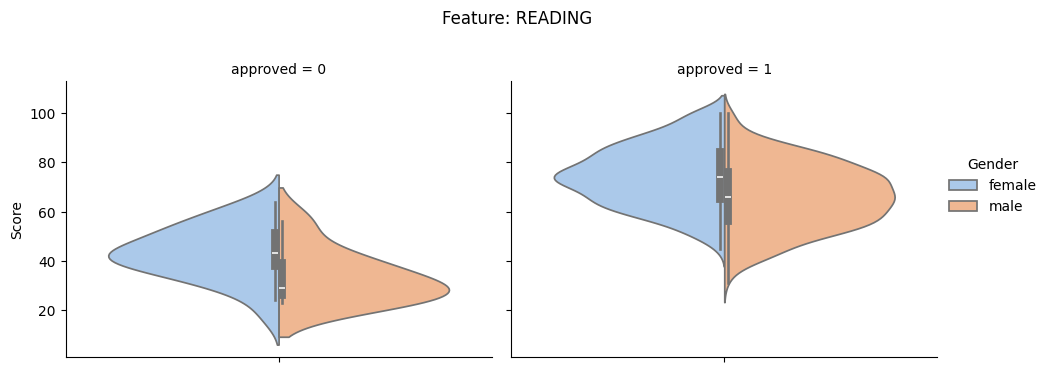

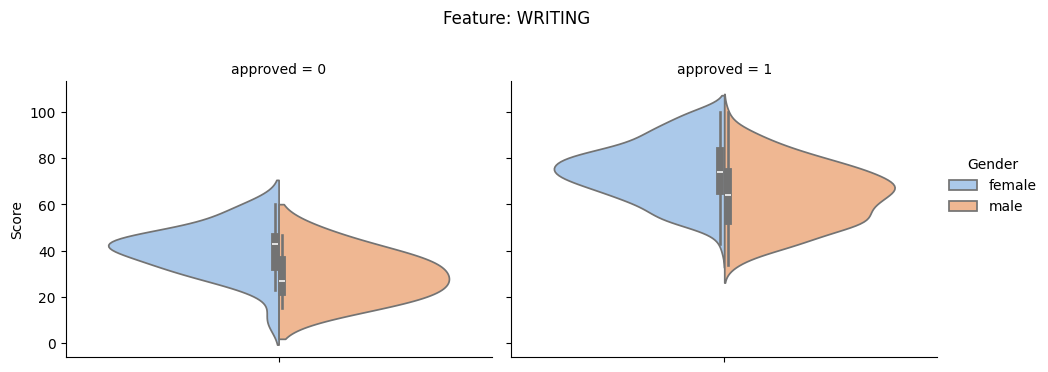

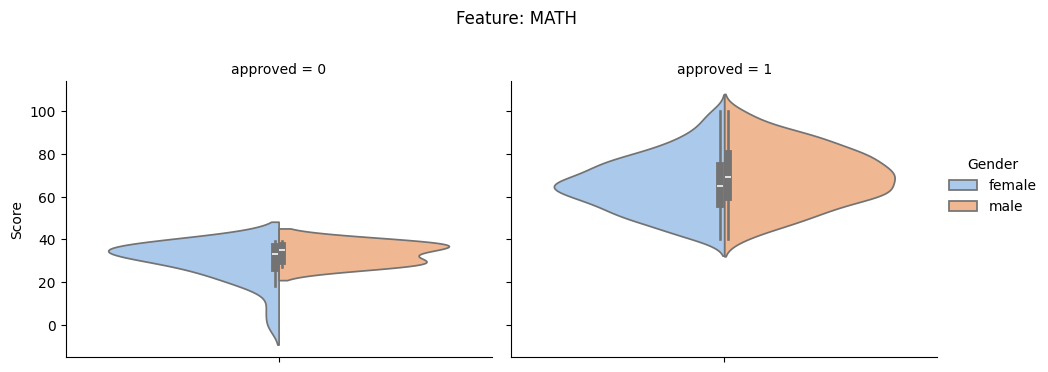

In [8]:
# Creamos una columna vacía para que Seaborn tenga algo que poner en el eje X
df['dummy'] = ''

for feature in ['reading', 'writing', 'math']:
    g = sns.FacetGrid(df, col='approved', sharey=True, height=4, aspect=1.2)
    # Mapeamos usando 'dummy' en X, y el puntaje en Y. Pasamos split=True y hue='gender'
    g.map(sns.violinplot, 'dummy', feature, 'gender', split=True, data=df, order=None, palette=palette)
    
    g.add_legend(title="Gender") # Mostrar leyenda
    g.set_ylabels('Score') # Nombre del eje Y
    g.set_xlabels('') # Ocultar el nombre del dummy
    
    g.fig.subplots_adjust(top=0.8)
    g.fig.suptitle(f'Feature: {feature.upper()}', fontsize=12, font='verdana')
    
# Borramos la columna basura para limpiar
del df['dummy']

---
## 4. Personalización Extrema: PairGrid 💎

📚 **Documentación:** [seaborn.PairGrid()](https://seaborn.pydata.org/generated/seaborn.PairGrid.html)

`PairGrid` es una gran herramienta que nos permite extender los gráficos automáticos de Seaborn (como `pairplot`) de una manera infinitamente personalizada.

Esto haría algo similar a `sns.pairplot(df)`, pero forzando a que en la diagonal no haya un histograma sino scatterplots.

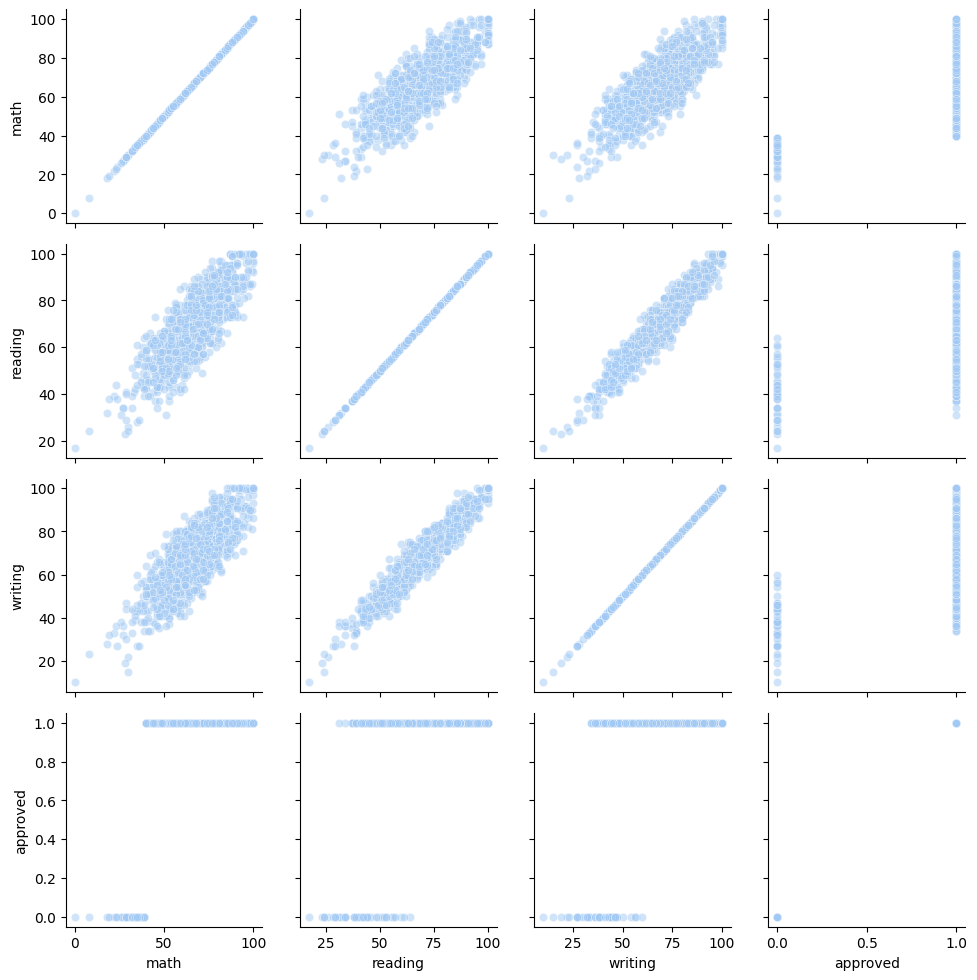

In [9]:
# Eliminaremos momentáneamente las dummies numéricas si las tuviéramos para no ensuciar
# del df['is_female'] 
# del df['is_male']

# Creamos el grid base evaluando todo el dataset
g = sns.PairGrid(df)
g.map(sns.scatterplot, alpha=0.5);

### 4.1 KDE Multivariado Personalizado
¿Quizás no has visto el verdadero poder de los PairGrids? 

Intentemos nuevamente usando la clase `PairGrid` para asignar funciones **diferentes** a la parte superior de la matriz, la parte inferior y la diagonal, alimentado con un mapa de colores (`cmap`) de paleta en hélice (cubehelix).

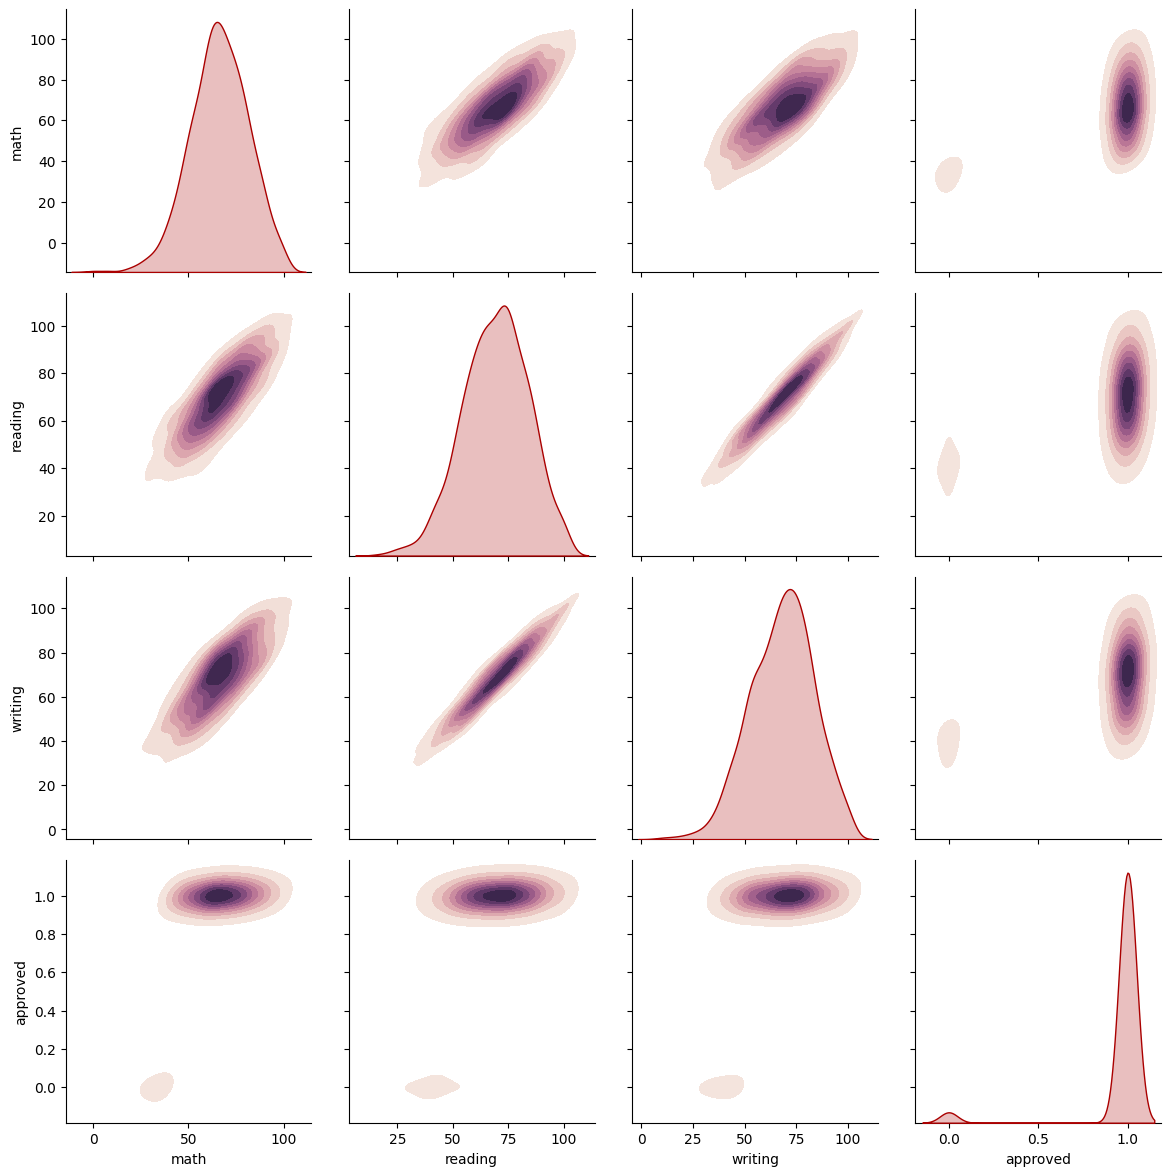

In [10]:
# Creamos una paleta geométrica cubehelix para usar con los mapas topográficos KDE
cmap = sns.cubehelix_palette(start=0, light=.95, as_cmap=True)

g = sns.PairGrid(df, diag_sharey=False, height=3)

# Parte superior de la matriz: KDE bivariado con paleta
g.map_upper(sns.kdeplot, cmap=cmap, fill=True)

# Parte inferior de la matriz: KDE bivariado con paleta
g.map_lower(sns.kdeplot, cmap=cmap, fill=True)

# Diagonal principal: KDE univariado (Rojo oscuro)
g.map_diag(sns.kdeplot, color='#aa0000', fill=True);

---
##### 🛠️ Práctica 2: Tu propio PairGrid
Usa la instancia base `g = sns.PairGrid(df)` y sus métodos de mapeo (`map_upper`, `map_lower`, `map_diag`).

Crea una matriz donde:
1. La **diagonal** sean histogramas clásicos (`sns.histplot`).
2. La **parte inferior** sean gráficos de dispersión (`sns.scatterplot`).
3. La **parte superior** sean KDE plots topográficos (`sns.kdeplot`).

In [11]:
# Escribe tu código aquí
# g = sns.PairGrid(df)
# g.map_...


<details>
<summary><b>💡 Haz clic aquí para ver la solución</b></summary>

```python
g = sns.PairGrid(df)
g.map_diag(sns.histplot, color='purple')
g.map_lower(sns.scatterplot, alpha=0.5, color='green')
g.map_upper(sns.kdeplot, fill=True, cmap='Blues')
```
</details>
